# Transfer Learning CIFAR10

* Train a simple convnet on the CIFAR dataset the first 5 output classes [0..4].
* Freeze convolutional layers and fine-tune dense layers for the last 5 ouput classes [5..9].


### 1. Import CIFAR10 data and create 2 datasets with one dataset having classes from 0 to 4 and other having classes from 5 to 9 

In [0]:
import keras
from keras.datasets import cifar10
%matplotlib inline

(X_train, y_train), (X_test, y_test) = cifar10.load_data() 


Label: [4]


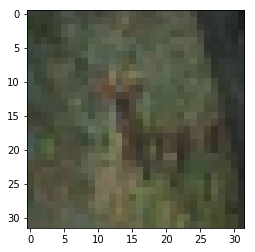

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
print("Label: {}".format(y_train[10]))
plt.imshow(X_train[10], cmap='gray')

In [4]:
import numpy as np

X_train_0_4 = np.asarray([X_train[key] for (key, label) in enumerate(y_train) if int(label) >= 0 and int(label) <= 4])
X_train_5_9 = np.asarray([X_train[key] for (key, label) in enumerate(y_train) if int(label) >= 5 and int(label) <= 9])

X_test_0_4 = np.asarray([X_test[key] for (key, label) in enumerate(y_test) if int(label) >= 0 and int(label) <= 4])
X_test_5_9 = np.asarray([X_test[key] for (key, label) in enumerate(y_test) if int(label) >= 5 and int(label) <= 9])

y_train_0_4 = np.asarray([y_train[key] for (key, label) in enumerate(y_train) if int(label) >= 0 and int(label) <= 4])
y_train_5_9 = np.asarray([y_train[key] for (key, label) in enumerate(y_train) if int(label) >= 5 and int(label) <= 9])

y_test_0_4 = np.asarray([y_test[key] for (key, label) in enumerate(y_test) if int(label) >= 0 and int(label) <= 4])
y_test_5_9 = np.asarray([y_test[key] for (key, label) in enumerate(y_test) if int(label) >= 5 and int(label) <= 9])

print("the array of y_train_0_4 is :",np.unique(y_train_0_4))
print("the array of y_train_5_9 is :",np.unique(y_train_5_9))
print("the array of y_test_0_4 is :",np.unique(y_test_0_4))
print("the array of y_test_5_9 is :",np.unique(y_test_5_9))

the array of y_train_0_4 is : [0 1 2 3 4]
the array of y_train_5_9 is : [5 6 7 8 9]
the array of y_test_0_4 is : [0 1 2 3 4]
the array of y_test_5_9 is : [5 6 7 8 9]


### 2. Use One-hot encoding to divide y_train and y_test into required no of output classes

In [5]:
import tensorflow as tf
y_train_0_4 = tf.keras.utils.to_categorical(y_train_0_4, num_classes=5)
y_test_0_4 = tf.keras.utils.to_categorical(y_test_0_4, num_classes=5)
print("the array of y_train_0_4 is :",np.unique(y_train_0_4))
print("the array of y_test_0_4 is :",np.unique(y_test_0_4))

the array of y_train_0_4 is : [0. 1.]
the array of y_test_0_4 is : [0. 1.]


In [6]:
y_train_5_9 = y_train_5_9 - 5
y_test_5_9 = y_test_5_9 - 5

num_class_59 = len(np.unique(y_train_5_9))
y_train_5_9 = tf.keras.utils.to_categorical(y_train_5_9, num_classes=num_class_59)
y_test_5_9 = tf.keras.utils.to_categorical(y_test_5_9, num_classes=num_class_59)
y_test_5_9[0:10]

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.]], dtype=float32)

### 3. Build a sequential neural network model which can classify the classes 0 to 4 of CIFAR10 dataset with at least 80% accuracy on test data

In [0]:
from keras.models import Sequential
from keras.layers import Dense
from keras import regularizers
from keras import optimizers

In [0]:
X_train_0_4 = X_train_0_4 / 255
X_test_0_4 = X_test_0_4 / 255

X_train_0_4 = X_train_0_4.astype('float32')
X_test_0_4 = X_test_0_4.astype('float32')

In [89]:
#Importing the necessary libraries 
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D
from keras.layers import Dropout, Flatten, GlobalAveragePooling2D

#Building up a Sequential model
model = Sequential()
conv1 = model.add(Conv2D(32, (3, 3), activation='relu',input_shape = X_train_0_4.shape[1:]))
conv2 = model.add(Conv2D(32, (3, 3), activation='relu'))
conv3 = model.add(Conv2D(64, (3, 3), activation='relu'))

model.add(GlobalAveragePooling2D())
model.add(Dense(5, activation='softmax'))
model.summary()

Model: "sequential_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_22 (Conv2D)           (None, 30, 30, 32)        896       
_________________________________________________________________
conv2d_23 (Conv2D)           (None, 28, 28, 32)        9248      
_________________________________________________________________
conv2d_24 (Conv2D)           (None, 26, 26, 64)        18496     
_________________________________________________________________
global_average_pooling2d_8 ( (None, 64)                0         
_________________________________________________________________
dense_8 (Dense)              (None, 5)                 325       
Total params: 28,965
Trainable params: 28,965
Non-trainable params: 0
_________________________________________________________________


In [0]:
model.compile(loss='binary_crossentropy', optimizer='adam',
              metrics=['accuracy'])

In [99]:
model.fit(X_train_0_4, y_train_0_4, batch_size=32, epochs=10, 
          verbose=1, validation_split=0.2, shuffle=True)

Train on 20000 samples, validate on 5000 samples
Epoch 1/10
   32/20000 [..............................] - ETA: 1:22 - loss: 0.4360 - acc: 0.7938

/usr/local/lib/python3.6/dist-packages/keras/engine/training.py:493: UserWarning: Discrepancy between trainable weights and collected trainable weights, did you set `model.trainable` without calling `model.compile` after ?
  'Discrepancy between trainable weights and collected trainable'


20000/20000 [==============================] - 83s 4ms/step - loss: 0.3712 - acc: 0.8312 - val_loss: 0.3614 - val_acc: 0.8366
Epoch 2/10
20000/20000 [==============================] - 83s 4ms/step - loss: 0.3513 - acc: 0.8422 - val_loss: 0.3613 - val_acc: 0.8365
Epoch 3/10
20000/20000 [==============================] - 84s 4ms/step - loss: 0.3429 - acc: 0.8462 - val_loss: 0.3508 - val_acc: 0.8398
Epoch 4/10
20000/20000 [==============================] - 83s 4ms/step - loss: 0.3325 - acc: 0.8524 - val_loss: 0.3283 - val_acc: 0.8524
Epoch 5/10
20000/20000 [==============================] - 84s 4ms/step - loss: 0.3226 - acc: 0.8565 - val_loss: 0.3223 - val_acc: 0.8577
Epoch 6/10
20000/20000 [==============================] - 83s 4ms/step - loss: 0.3180 - acc: 0.8594 - val_loss: 0.3202 - val_acc: 0.8592
Epoch 7/10
20000/20000 [==============================] - 83s 4ms/step - loss: 0.3103 - acc: 0.8644 - val_loss: 0.3086 - val_acc: 0.8630
Epoch 8/10
20000/20000 [============================

In [100]:
score = model.evaluate(X_test_0_4, y_test_0_4)
#Accuracy on test data
print('Accuracy on the Test Images: ', score[1])

5000/5000 [==============================] - 5s 981us/step
Accuracy on the Test Images:  0.8637999919891357


### 4. In the model which was built above (for classification of classes 0-4 in CIFAR10), make only the dense layers to be trainable and conv layers to be non-trainable

In [101]:
#Set pre-trained model layers to not trainable
for layer in model.layers[:-2]:
 print(layer)
for layer in model.layers[:-2]:
    layer.trainable = False

In [102]:
for layer in model.layers:
    print(layer, layer.trainable)

<keras.layers.convolutional.Conv2D object at 0x7f06322ce128> False
<keras.layers.convolutional.Conv2D object at 0x7f063228ca58> False
<keras.layers.convolutional.Conv2D object at 0x7f0632e74f60> False
<keras.layers.pooling.GlobalAveragePooling2D object at 0x7f06327b41d0> True
<keras.layers.core.Dense object at 0x7f06322a42b0> True


### 5. Utilize the the model trained on CIFAR 10 (classes 0 to 4) to classify the classes 5 to 9 of CIFAR 10  (Use Transfer Learning) <br>
Achieve an accuracy of more than 85% on test data

In [106]:
model2 = model(weights='model', include_top=False, input_shape=X_train_5_9.shape[1:])

TypeError: ignored

In [0]:
X_train_5_9 = X_train_0_4 / 255
X_test_5_9 = X_test_0_4 / 255

X_train_5_9 = X_train_0_4.astype('float32')
X_test_5_9 = X_test_0_4.astype('float32')

# Text classification using TF-IDF

### 6. Load the dataset from sklearn.datasets

In [0]:
from sklearn.datasets import fetch_20newsgroups

In [0]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

### 7. Training data

In [0]:
twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)

### 8. Test data

In [0]:
twenty_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

###  a.  You can access the values for the target variable using .target attribute 
###  b. You can access the name of the class in the target variable with .target_names


In [111]:
twenty_train.target

array([1, 1, 3, ..., 2, 2, 2])

In [112]:
twenty_train.target_names

['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']

In [113]:
twenty_train.data[0:5]

['From: sd345@city.ac.uk (Michael Collier)\nSubject: Converting images to HP LaserJet III?\nNntp-Posting-Host: hampton\nOrganization: The City University\nLines: 14\n\nDoes anyone know of a good way (standard PC application/PD utility) to\nconvert tif/img/tga files into LaserJet III format.  We would also like to\ndo the same, converting to HPGL (HP plotter) files.\n\nPlease email any response.\n\nIs this the correct group?\n\nThanks in advance.  Michael.\n-- \nMichael Collier (Programmer)                 The Computer Unit,\nEmail: M.P.Collier@uk.ac.city                The City University,\nTel: 071 477-8000 x3769                      London,\nFax: 071 477-8565                            EC1V 0HB.\n',
 "From: ani@ms.uky.edu (Aniruddha B. Deglurkar)\nSubject: help: Splitting a trimming region along a mesh \nOrganization: University Of Kentucky, Dept. of Math Sciences\nLines: 28\n\n\n\n\tHi,\n\n\tI have a problem, I hope some of the 'gurus' can help me solve.\n\n\tBackground of the probl

### 9.  Now with dependent and independent data available for both train and test datasets, using TfidfVectorizer fit and transform the training data and test data and get the tfidf features for both

### 10. Use logisticRegression with tfidf features as input and targets as output and train the model and report the train and test accuracy score